In [ ]:
!pip install rank-bm25 fuzzywuzzy python-Levenshtein sentence-transformers -q


from rank_bm25 import BM25Okapi
from fuzzywuzzy import fuzz
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np


class BM25Retriever:
    """Lexical retrieval using BM25 algorithm"""

    def __init__(self, documents):
        self.documents = documents
        self.corpus = []
        for doc in documents:
            text = (doc.get('title', '') + ' ' + doc.get('body', '')).lower()
            tokens = text.split()
            self.corpus.append(tokens)
        self.bm25 = BM25Okapi(self.corpus)

    def search(self, query, top_k=10):
        query_tokens = query.lower().split()
        scores = self.bm25.get_scores(query_tokens)
        top_indices = np.argsort(scores)[::-1][:top_k]

        results = []
        for idx in top_indices:
            if scores[idx] > 0:
                results.append({
                    'doc': self.documents[idx],
                    'score': float(scores[idx]),
                    'method': 'BM25'
                })
        return results


class FuzzyMatcher:
    """Fuzzy string matching for cross-script queries"""

    def __init__(self, documents):
        self.documents = documents

    def fuzzy_score(self, query, text):
        return fuzz.token_set_ratio(query.lower(), text.lower()) / 100.0

    def search(self, query, top_k=10):
        scores = []
        for doc in self.documents:
            text = doc.get('title', '') + ' ' + doc.get('body', '')[:500]
            score = self.fuzzy_score(query, text)
            scores.append({
                'doc': doc,
                'score': score,
                'method': 'Fuzzy'
            })
        scores.sort(key=lambda x: x['score'], reverse=True)
        return scores[:top_k]


class SemanticRetriever:
    """Semantic retrieval using multilingual embeddings"""

    def __init__(self, documents, model_name='LaBSE'):
        self.documents = documents
        self.model_name = model_name
        self.model = SentenceTransformer('sentence-transformers/LaBSE')
        self.doc_embeddings = None

    def search(self, query, top_k=10):
        if self.doc_embeddings is None:
            return []

        query_embedding = self.model.encode(query, convert_to_tensor=True)
        scores = util.cos_sim(query_embedding, self.doc_embeddings)[0]
        top_indices = torch.argsort(scores, descending=True)[:top_k]

        results = []
        for idx in top_indices:
            results.append({
                'doc': self.documents[idx.item()],
                'score': float(scores[idx]),
                'method': 'Semantic'
            })
        return results


class HybridRanker:
    """Combine multiple retrieval models with weighted scoring"""

    def __init__(self, bm25, fuzzy, semantic, weights=(0.3, 0.2, 0.5)):
        self.bm25 = bm25
        self.fuzzy = fuzzy
        self.semantic = semantic
        self.weights = weights

    def normalize_scores(self, results):
        if not results:
            return results

        scores = [r['score'] for r in results]
        min_score = min(scores)
        max_score = max(scores)

        if max_score == min_score:
            for r in results:
                r['score'] = 1.0
            return results

        for r in results:
            r['score'] = (r['score'] - min_score) / (max_score - min_score)
        return results

    def search(self, query, top_k=10):
        # Get results from all models
        bm25_results = self.bm25.search(query, top_k=50)
        fuzzy_results = self.fuzzy.search(query, top_k=50)
        semantic_results = self.semantic.search(query, top_k=50)

        # Normalize scores
        bm25_results = self.normalize_scores(bm25_results)
        fuzzy_results = self.normalize_scores(fuzzy_results)
        semantic_results = self.normalize_scores(semantic_results)

        # Combine scores by document URL
        combined = {}

        for r in bm25_results:
            url = r['doc']['url']
            if url not in combined:
                combined[url] = {
                    'doc': r['doc'],
                    'bm25_score': 0,
                    'fuzzy_score': 0,
                    'semantic_score': 0,
                    'methods': []
                }
            combined[url]['bm25_score'] = r['score']
            combined[url]['methods'].append('BM25')

        for r in fuzzy_results:
            url = r['doc']['url']
            if url not in combined:
                combined[url] = {
                    'doc': r['doc'],
                    'bm25_score': 0,
                    'fuzzy_score': 0,
                    'semantic_score': 0,
                    'methods': []
                }
            combined[url]['fuzzy_score'] = r['score']
            combined[url]['methods'].append('Fuzzy')

        for r in semantic_results:
            url = r['doc']['url']
            if url not in combined:
                combined[url] = {
                    'doc': r['doc'],
                    'bm25_score': 0,
                    'fuzzy_score': 0,
                    'semantic_score': 0,
                    'methods': []
                }
            combined[url]['semantic_score'] = r['score']
            combined[url]['methods'].append('Semantic')

        # Calculate weighted combined score
        for url in combined:
            combined[url]['score'] = (
                combined[url]['bm25_score'] * self.weights[0] +
                combined[url]['fuzzy_score'] * self.weights[1] +
                combined[url]['semantic_score'] * self.weights[2]
            )
            combined[url]['method'] = 'Hybrid'

        # Sort by combined score
        final_results = sorted(
            combined.values(),
            key=lambda x: x['score'],
            reverse=True
        )

        return final_results[:top_k]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.7 MB/s eta 0:00:00


In [ ]:
import pickle
import time
import os

!pip install gdown
import gdown

def download_retrieval_system():
    file_id = '1YK4ERCCwlo7VTjIF4gQZUj7SfMg3Vf_T'
    url = f'https://drive.google.com/uc?id={file_id}'
    output = 'retrieval_system.pkl'

    if not os.path.exists(output):
        print(f"File '{output}' not found locally. Downloading from Google Drive...")
        try:
            gdown.download(url, output, quiet=False)
            print("\nDownload complete.")
        except Exception as e:
            print(f"Failed to download file: {e}")
            sys.exit(1)
    else:
        print(f"File '{output}' already exists. Skipping download.")

# Perform the download check before loading
download_retrieval_system()


File 'retrieval_system.pkl' not found locally. Downloading from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1YK4ERCCwlo7VTjIF4gQZUj7SfMg3Vf_T
From (redirected): https://drive.google.com/uc?id=1YK4ERCCwlo7VTjIF4gQZUj7SfMg3Vf_T&confirm=t&uuid=8d309080-e830-4529-ad48-a5c2e9bf7b63
To: /content/retrieval_system.pkl
100%|██████████| 1.99G/1.99G [00:22<00:00, 87.2MB/s]


Download complete.


In [ ]:
# Load the retrieval system
print("Loading retrieval system...")
with open('retrieval_system.pkl', 'rb') as f:
    system = pickle.load(f)

# Extract all components
hybrid = system['hybrid']
bm25 = system['bm25']
semantic = system['semantic']
fuzzy = system['fuzzy']
all_docs = system['documents']

print(f"✓ System loaded: {len(all_docs)} documents")




Loading retrieval system...
✓ System loaded: 6188 documents


In [ ]:
import numpy as np

def dcg_at_k(r, k):
    """Score is discounted based on the rank of the result"""
    r = np.asarray(r, dtype=float)[:k]
    if r.size:
        return np.sum(r / np.log2(np.arange(2, r.size + 2)))
    return 0.0

def ndcg_at_k(results, relevant_urls, k=10):
    """
    Normalized Discounted Cumulative Gain
    results: list of search result dicts
    relevant_urls: list/set of relevant urls (binary relevance assumed here)
    """
    # Create binary relevance vector (1 if relevant, 0 if not)
    relevance_vector = [1 if r['doc']['url'] in relevant_urls else 0 for r in results]

    # Calculate DCG for the actual results
    dcg = dcg_at_k(relevance_vector, k)

    # Calculate Ideal DCG (IDCG) - perfect ordering
    ideal_vector = sorted(relevance_vector, reverse=True)
    idcg = dcg_at_k(ideal_vector, k)

    if idcg == 0:
        return 0.0
    return dcg / idcg

def precision_at_k(results, relevant_urls, k=10):
    """
    Calculates Precision@K: % of top-K results that are relevant.
    """
    if k <= 0: return 0.0

    # Slice the top k results
    top_k = results[:k]

    # Count how many of these are in the relevant_urls set
    relevant_found = sum(1 for r in top_k if r['doc']['url'] in relevant_urls)

    return relevant_found / k

def recall_at_k(results, relevant_urls, k=50):
    """
    Calculates Recall@K: % of ALL relevant documents found in the top-K.
    """
    if not relevant_urls: return 0.0

    top_k = results[:k]
    relevant_found = sum(1 for r in top_k if r['doc']['url'] in relevant_urls)

    return relevant_found / len(relevant_urls)

def mrr(results, relevant_urls):
    """
    Calculates Mean Reciprocal Rank: 1 / (rank of first relevant result).
    """
    for i, r in enumerate(results, 1):
        if r['doc']['url'] in relevant_urls:
            return 1.0 / i
    return 0.0

def load_ground_truth(filepath='relevant_labels.csv'):
    try:
        df = pd.read_csv(filepath)
        gt = defaultdict(set)
        for _, row in df.iterrows():
            if row['relevance_score'] > 0:
                gt[row['query']].add(row['doc_url'])
        return gt
    except FileNotFoundError:
        print("⚠ relevance_labels.csv not found. Using sample queries.")
        return {}


In [ ]:
def search_with_metrics(query):
    """Search with timing and confidence metrics"""
    start = time.time()
    results = hybrid.search(query, top_k=10)
    elapsed_ms = (time.time() - start) * 1000

    # Calculate confidence
    if results:
        top_score = results[0]['score']
        if top_score >= 0.7:
            confidence = "🟢 High"
            warning = None
        elif top_score >= 0.4:
            confidence = "🟡 Medium"
            warning = None
        else:
            confidence = "🔴 Low"
            warning = "⚠ Low confidence. Try rephrasing your query."
    else:
        confidence = "None"
        warning = "No results found."

    return {
        'results': results,
        'time_ms': elapsed_ms,
        'confidence': confidence,
        'warning': warning
    }


# Test queries
test_queries = [
    {
        'query': 'cricket in Bangladesh',
        'relevant_urls': [
            # Add relevant URLs from your dataset here
        ]
    },
    {
        'query': 'নির্বাচন',
        'relevant_urls': []
    },
    {
        'query': 'university education',
        'relevant_urls': []
    }
]


# Interactive search
def interactive_search():
    """Interactive search mode"""
    print("\n" + "="*70)
    print("CROSS-LINGUAL SEARCH SYSTEM - Module D")
    print("="*70)
    print("\nCommands:")
    print("  - Type your query to search")
    print("  - 'eval' to run evaluation")
    print("  - 'quit' to exit")
    print()

    while True:
        query = input("\nEnter query: ").strip()

        if query.lower() == 'quit':
            print("Goodbye!")
            break

        if query.lower() == 'eval':
            run_evaluation()
            continue

        if not query:
            continue

        # Search
        result = search_with_metrics(query)

        # Display results
        print(f"\n{'='*70}")
        print(f"Query: '{query}'")
        print(f"Time: {result['time_ms']:.1f}ms | Confidence: {result['confidence']}")
        if result['warning']:
            print(f"{result['warning']}")
        print('='*70)

        for i, r in enumerate(result['results'][:5], 1):
            print(f"\n[{i}] Score: {r['score']:.3f}")
            print(f"    {r['doc']['title'][:70]}")
            print(f"    Language: {r['doc']['language']}")
            if 'methods' in r:
                print(f"    Methods: {', '.join(set(r['methods']))}")


def run_evaluation():
    """Run evaluation on test queries"""
    if not any(q['relevant_urls'] for q in test_queries):
        print("\n⚠ No relevant URLs defined in test_queries")
        print("Add relevant URLs to calculate metrics")
        return

    print("\nRunning evaluation...")
    evaluation_results = []

    for query_data in test_queries:
        results = hybrid.search(query_data['query'], top_k=50)
        eval_result = {
            'query': query_data['query'],
            'precision_at_10': precision_at_k(results, query_data['relevant_urls'], k=10),
            'recall_at_50': recall_at_k(results, query_data['relevant_urls'], k=50),
            'mrr': mrr(results, query_data['relevant_urls'])
        }
        evaluation_results.append(eval_result)

    # Calculate averages
    avg_p10 = sum(r['precision_at_10'] for r in evaluation_results) / len(evaluation_results)
    avg_r50 = sum(r['recall_at_50'] for r in evaluation_results) / len(evaluation_results)
    avg_mrr = sum(r['mrr'] for r in evaluation_results) / len(evaluation_results)

    print(f"\nEvaluation Results:")
    print(f"  Precision@10: {avg_p10:.3f} (target: ≥0.6)")
    print(f"  Recall@50: {avg_r50:.3f} (target: ≥0.5)")
    print(f"  MRR: {avg_mrr:.3f} (target: ≥0.4)")

#run interactive search
interactive_search()

In [ ]:
import time
import pandas as pd
from collections import defaultdict

class Evaluator:
    def __init__(self, retrieval_system, ground_truth_file):
        self.system = retrieval_system
        self.ground_truth = self._load_ground_truth(ground_truth_file)

    def _load_ground_truth(self, filepath):
        """Loads CSV: query, doc_url, relevance_score"""
        try:
            df = pd.read_csv(filepath)
            # Group by query -> set of relevant URLs
            gt = defaultdict(set)
            for _, row in df.iterrows():
                if row['relevance_score'] > 0:
                    gt[row['query']].add(row['doc_url'])
            return gt
        except FileNotFoundError:
            print("⚠ relevance_labels.csv not found. Using empty ground truth.")
            return {}

    def analyze_errors(self, query, results, relevant_urls, top_k=10):
        """Deep dive into why a query failed"""
        top_urls = [r['doc']['url'] for r in results[:top_k]]
        missed = list(relevant_urls - set(top_urls))

        print(f"\n🔍 ERROR ANALYSIS for: '{query}'")
        print(f"   Relevant Docs Found: {len(relevant_urls.intersection(top_urls))}/{len(relevant_urls)}")

        if missed:
            print("   ❌ Missed Documents (Not in Top 10):")
            for url in missed[:3]:
                print(f"      - {url}")

            # Diagnosis: Check why they were missed
            print("   🩺 Diagnostics:")
            # Check if doc exists in corpus at all
            doc_exists = any(d['url'] == missed[0] for d in self.system.bm25.documents)
            if not doc_exists:
                print("      ⚠ CRITICAL: Relevant document NOT found in index/corpus.")
            else:
                print("      ⚠ Document exists but ranked too low. Possible issues:")
                print("         1. Term mismatch (Try Fuzzy/Semantic weights)")
                print("         2. Language script mismatch")

    def profile_performance(self, query):
        """Breakdown of retrieval time"""
        times = {}

        # 1. Embedding Time (Semantic)
        t0 = time.time()
        _ = self.system.semantic.model.encode(query)
        times['Embedding Generation'] = (time.time() - t0) * 1000

        # 2. Retrieval Time (Full Hybrid)
        t0 = time.time()
        _ = self.system.search(query, top_k=10)
        times['Total Retrieval'] = (time.time() - t0) * 1000

        # Approximate ranking/fusion time
        times['Ranking & Fusion'] = times['Total Retrieval'] - times['Embedding Generation']

        return times

    def run_full_evaluation(self):
        print("\n" + "="*60)
        print("🚀 STARTING SYSTEM EVALUATION")
        print("="*60)

        metrics = {
            'p@10': [],
            'r@50': [],
            'ndcg@10': [],
            'mrr': []
        }

        if not self.ground_truth:
            print("No ground truth data found. Skipping metrics.")
            return

        for query, relevant_urls in self.ground_truth.items():
            # Search
            results = self.system.search(query, top_k=50)

            # Calculate Metrics
            p10 = precision_at_k(results, relevant_urls, k=10)
            r50 = recall_at_k(results, relevant_urls, k=50)
            ndcg10 = ndcg_at_k(results, relevant_urls, k=10)
            mrr_score = mrr(results, relevant_urls)

            metrics['p@10'].append(p10)
            metrics['r@50'].append(r50)
            metrics['ndcg@10'].append(ndcg10)
            metrics['mrr'].append(mrr_score)

            # Trigger Error Analysis for poor performing queries
            if p10 < 0.2:  # Threshold for detailed analysis
                self.analyze_errors(query, results, relevant_urls)

        # Averages
        print("\n📊 FINAL METRICS REPORT")
        print("-" * 30)
        print(f"Precision@10: {np.mean(metrics['p@10']):.3f}  (Target: ≥0.6) {'✅' if np.mean(metrics['p@10']) >= 0.6 else '❌'}")
        print(f"Recall@50:    {np.mean(metrics['r@50']):.3f}  (Target: ≥0.5) {'✅' if np.mean(metrics['r@50']) >= 0.5 else '❌'}")
        print(f"nDCG@10:      {np.mean(metrics['ndcg@10']):.3f}  (Target: ≥0.5) {'✅' if np.mean(metrics['ndcg@10']) >= 0.5 else '❌'}")
        print(f"MRR:          {np.mean(metrics['mrr']):.3f}  (Target: ≥0.4) {'✅' if np.mean(metrics['mrr']) >= 0.4 else '❌'}")

        # Time Profiling (Sample)
        print("\n⏱ PERFORMANCE PROFILING (Sample Query)")
        sample_q = list(self.ground_truth.keys())[0]
        timings = self.profile_performance(sample_q)
        for stage, ms in timings.items():
            print(f"  - {stage}: {ms:.2f} ms")


# --- Integration Helper --
if __name__ == "__main__":
    # 2. Run Evaluator
    evaluator = Evaluator(hybrid, 'relevant_labels.csv')
    evaluator.run_full_evaluation()


🚀 STARTING SYSTEM EVALUATION

🔍 ERROR ANALYSIS for: 'surveillance state awami league'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'July uprising victims bodies'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'Jucsu election vote counting'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'punishment for students involved in violence'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'Nepal Gen Z protests causes'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'reinstated candidates Rucsu polls'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'Jucsu election vote rigging allegations'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'illegal bus stands Old Dhaka'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'Bangladesh football team Nepal safety'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'Rucsu candidate list cancellation'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS for: 'DU law professor denied bail'
   Relevant Docs Found: 1/1

🔍 ERROR ANALYSIS fo

Evaluating all models...
✓ Evaluation complete!

📊 MODEL COMPARISON TABLE
   Model  Precision@10  Recall@50  nDCG@10      MRR
    BM25      0.100000   1.000000 0.892853 0.855556
   Fuzzy      0.093333   0.933333 0.887698 0.875000
Semantic      0.080000   0.933333 0.679502 0.643627
  Hybrid      0.100000   1.000000 0.906346 0.876190


📋 PER-QUERY PERFORMANCE (First 5 queries)
                                       Query    Model  Precision@10  Recall@50  nDCG@10      MRR
             surveillance state awami league     BM25           0.1        1.0 0.630930 0.500000
             surveillance state awami league    Fuzzy           0.1        1.0 1.000000 1.000000
             surveillance state awami league Semantic           0.0        0.0 0.000000 0.000000
             surveillance state awami league   Hybrid           0.1        1.0 0.630930 0.500000
                July uprising victims bodies     BM25           0.1        1.0 1.000000 1.000000
                July uprising victims bo

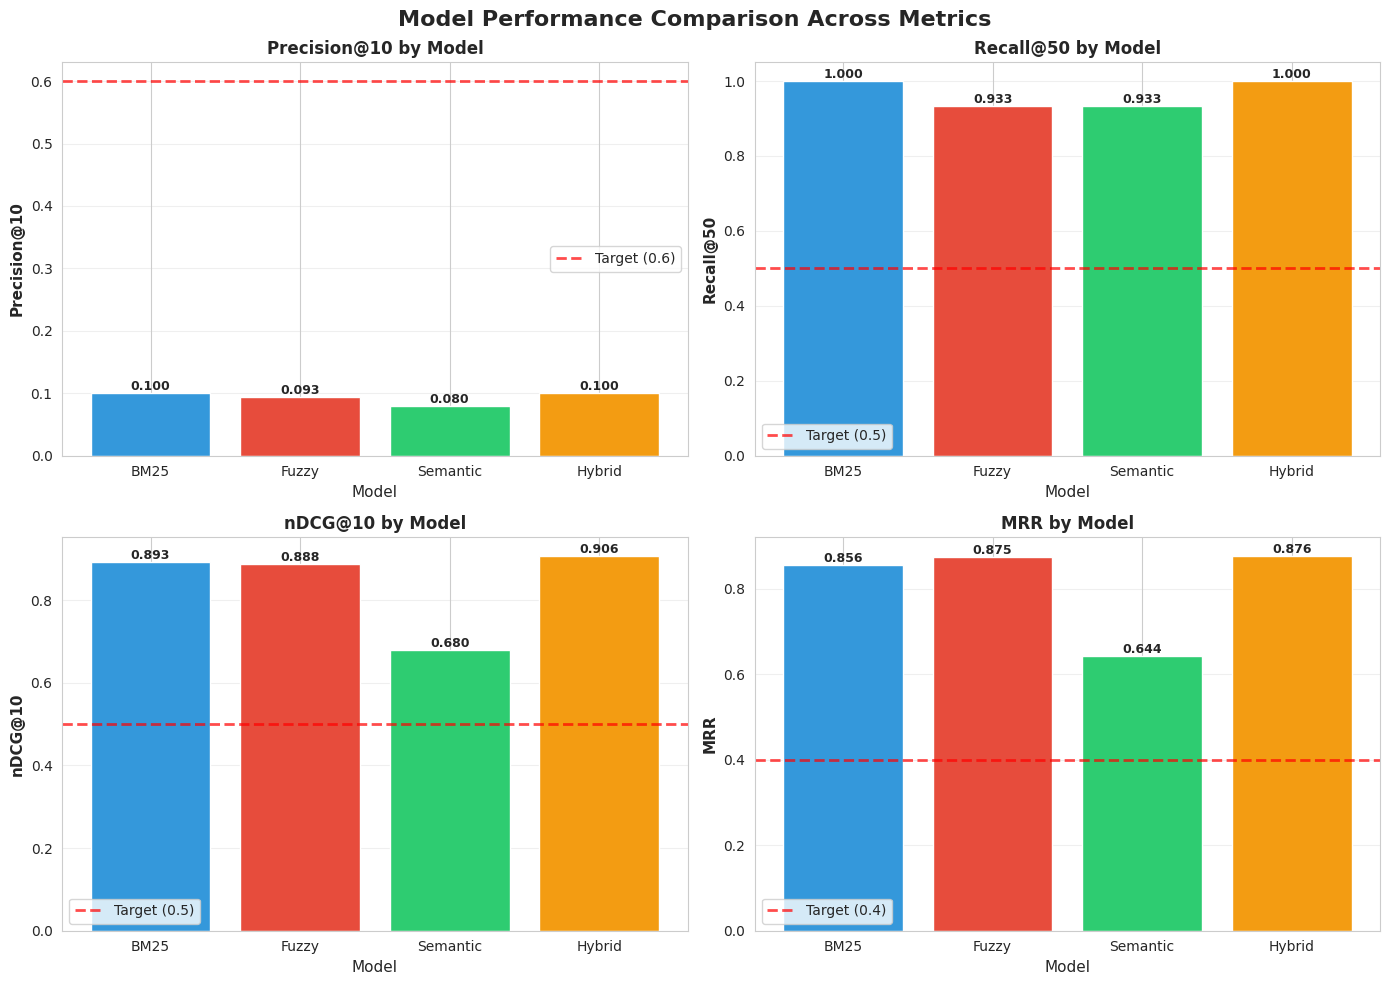

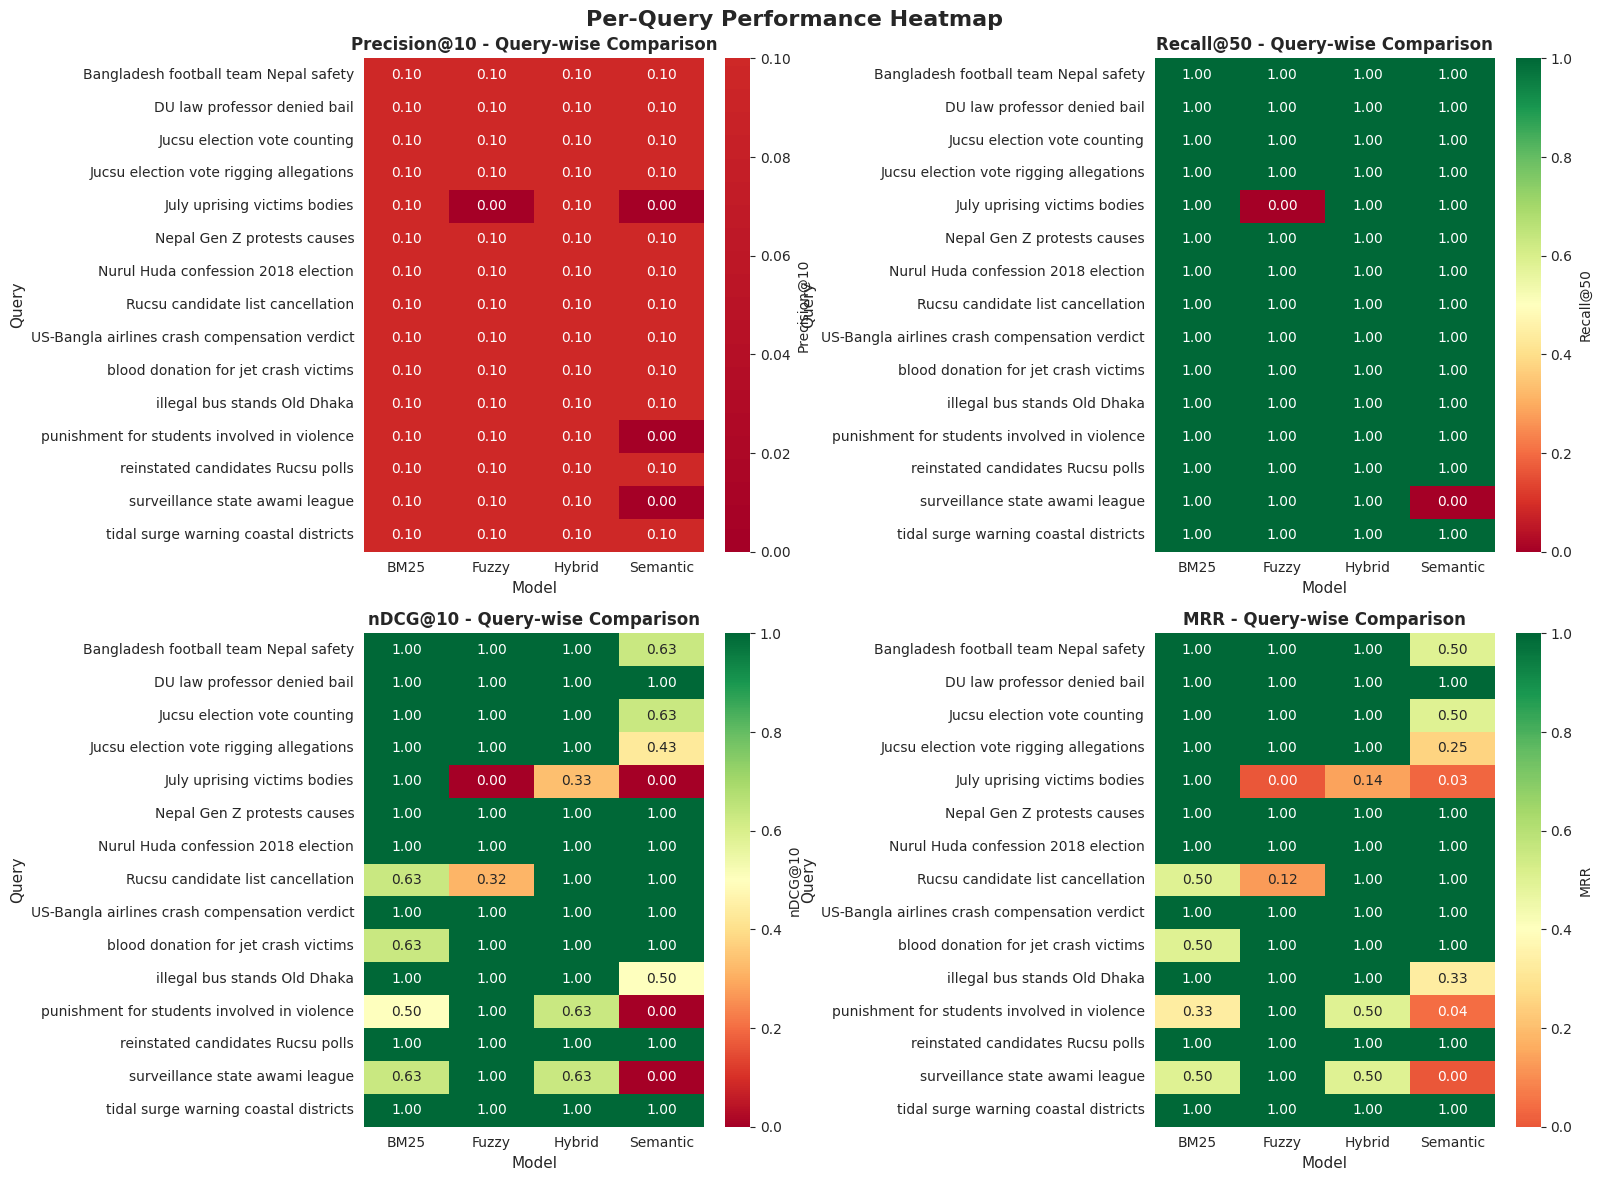

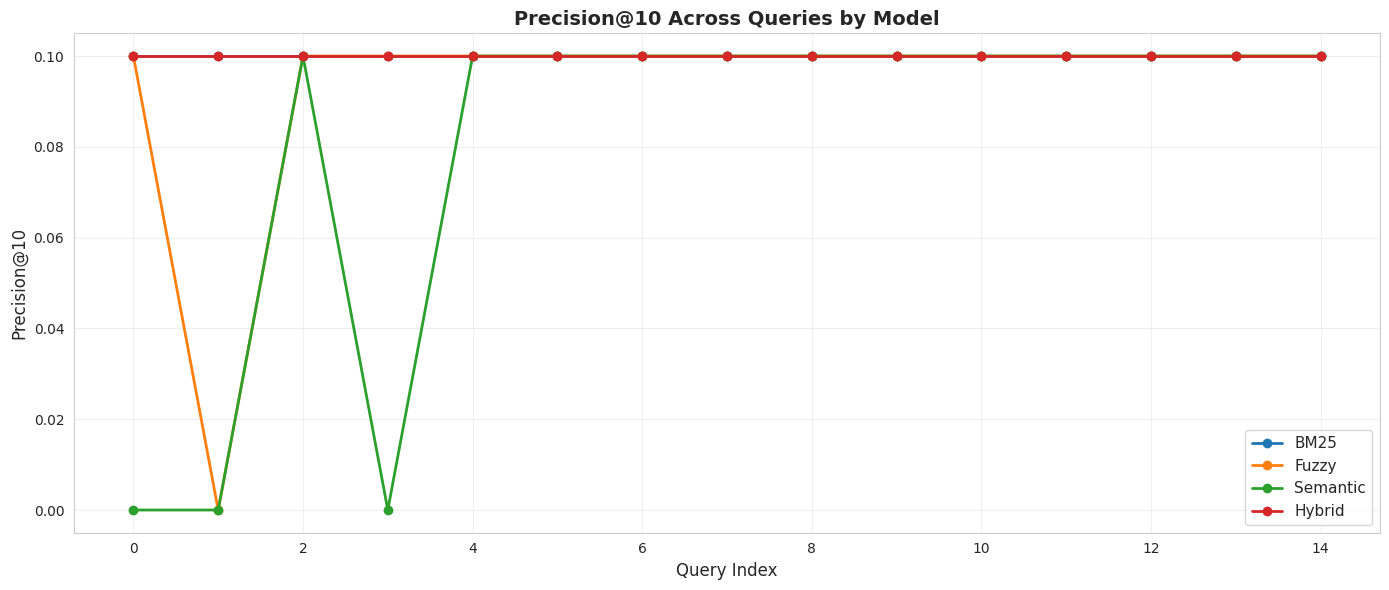

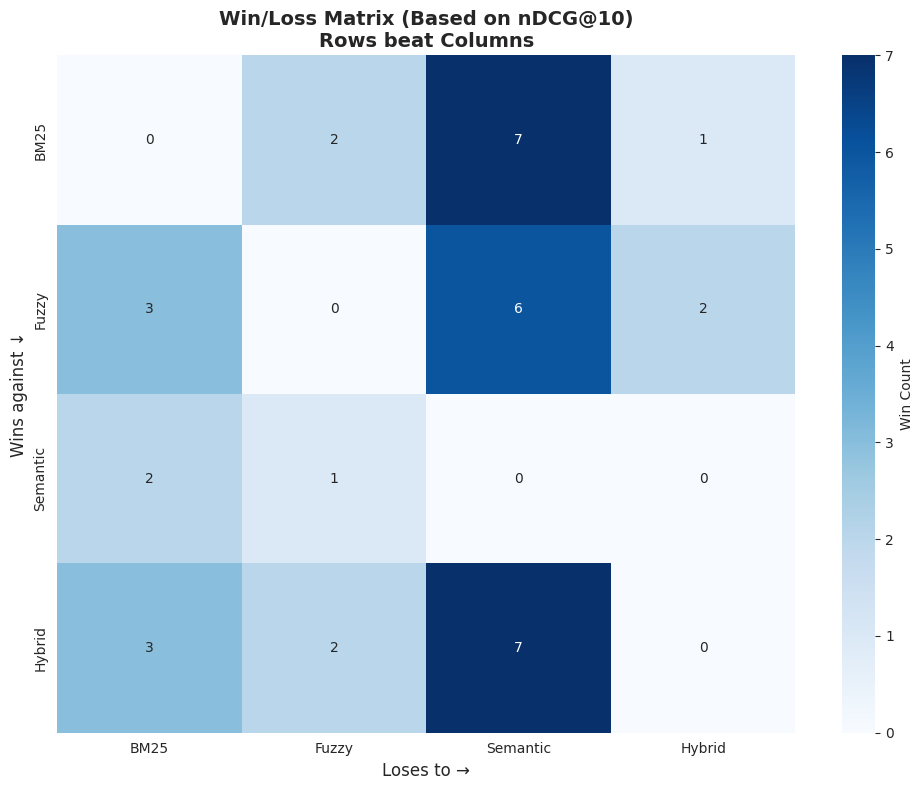

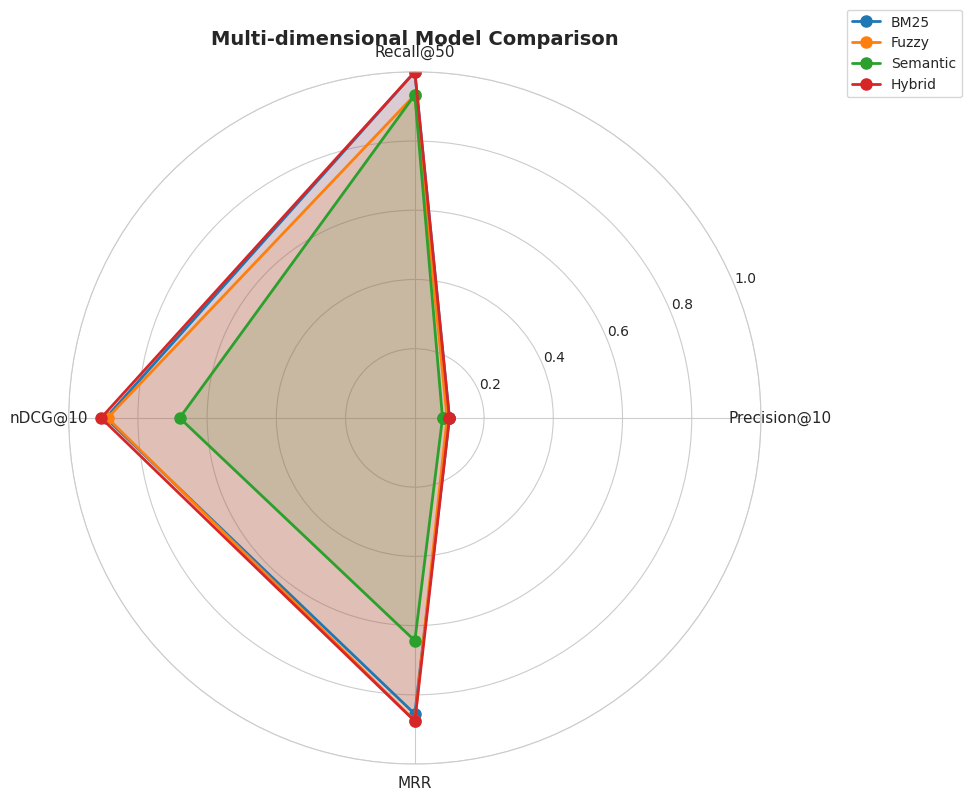

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# LOAD GROUND TRUTH
ground_truth = load_ground_truth()

# EVALUATE ALL MODELS
def evaluate_model(retriever, model_name, ground_truth, top_k_retrieve=50):
    """Evaluate a single retrieval model"""
    results = {
        'model': model_name,
        'p@10': [],
        'r@50': [],
        'ndcg@10': [],
        'mrr': [],
        'queries': []
    }

    for query, relevant_urls in ground_truth.items():
        search_results = retriever.search(query, top_k=top_k_retrieve)

        results['p@10'].append(precision_at_k(search_results, relevant_urls, k=10))
        results['r@50'].append(recall_at_k(search_results, relevant_urls, k=50))
        results['ndcg@10'].append(ndcg_at_k(search_results, relevant_urls, k=10))
        results['mrr'].append(mrr(search_results, relevant_urls))
        results['queries'].append(query)

    return results

print("Evaluating all models...")
print("=" * 60)

# Evaluate each model
bm25_results = evaluate_model(bm25, 'BM25', ground_truth)
fuzzy_results = evaluate_model(fuzzy, 'Fuzzy', ground_truth)
semantic_results = evaluate_model(semantic, 'Semantic', ground_truth)
hybrid_results = evaluate_model(hybrid, 'Hybrid', ground_truth)

print("✓ Evaluation complete!\n")

# ============================================================================
# CREATE COMPARISON TABLE
# ============================================================================
def create_comparison_table(all_results):
    """Create summary statistics table"""
    data = []
    for result in all_results:
        data.append({
            'Model': result['model'],
            'Precision@10': np.mean(result['p@10']),
            'Recall@50': np.mean(result['r@50']),
            'nDCG@10': np.mean(result['ndcg@10']),
            'MRR': np.mean(result['mrr'])
        })

    df = pd.DataFrame(data)
    return df

comparison_df = create_comparison_table([bm25_results, fuzzy_results, semantic_results, hybrid_results])

print("📊 MODEL COMPARISON TABLE")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("\n")

# ============================================================================
# DETAILED PER-QUERY ANALYSIS
# ============================================================================
def create_perquery_dataframe(all_results):
    """Create detailed per-query comparison"""
    data = []
    queries = all_results[0]['queries']

    for i, query in enumerate(queries):
        for result in all_results:
            data.append({
                'Query': query,
                'Model': result['model'],
                'Precision@10': result['p@10'][i],
                'Recall@50': result['r@50'][i],
                'nDCG@10': result['ndcg@10'][i],
                'MRR': result['mrr'][i]
            })

    return pd.DataFrame(data)

perquery_df = create_perquery_dataframe([bm25_results, fuzzy_results, semantic_results, hybrid_results])

print("📋 PER-QUERY PERFORMANCE (First 5 queries)")
print("=" * 60)
print(perquery_df.head(20).to_string(index=False))
print("\n")

# ============================================================================
# VISUALIZATIONS
# ============================================================================
print("Creating visualizations...")

# 1. BAR CHART - Overall Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison Across Metrics', fontsize=16, fontweight='bold')

metrics = ['Precision@10', 'Recall@50', 'nDCG@10', 'MRR']
targets = [0.6, 0.5, 0.5, 0.4]  # Target thresholds

for idx, (metric, target) in enumerate(zip(metrics, targets)):
    ax = axes[idx // 2, idx % 2]

    # Create bar chart
    bars = ax.bar(comparison_df['Model'], comparison_df[metric],
                   color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])

    # Add target line
    ax.axhline(y=target, color='red', linestyle='--', linewidth=2,
               label=f'Target ({target})', alpha=0.7)

    # Customize
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11)
    ax.set_title(f'{metric} by Model', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=300, bbox_inches='tight')
print("✓ Saved: model_comparison_bars.png")

# 2. HEATMAP - Per-Query Performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Per-Query Performance Heatmap', fontsize=16, fontweight='bold')

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    # Pivot data for heatmap
    pivot_data = perquery_df.pivot(index='Query', columns='Model', values=metric)

    # Create heatmap
    sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlGn',
                center=targets[idx], ax=ax, cbar_kws={'label': metric})

    ax.set_title(f'{metric} - Query-wise Comparison', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel('Query', fontsize=11)

plt.tight_layout()
plt.savefig('perquery_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: perquery_heatmap.png")

# 3. LINE PLOT - Metric Trends Across Queries
fig, ax = plt.subplots(figsize=(14, 6))

for model in ['BM25', 'Fuzzy', 'Semantic', 'Hybrid']:
    model_data = perquery_df[perquery_df['Model'] == model]
    ax.plot(range(len(model_data)), model_data['Precision@10'],
            marker='o', label=model, linewidth=2, markersize=6)

ax.set_xlabel('Query Index', fontsize=12)
ax.set_ylabel('Precision@10', fontsize=12)
ax.set_title('Precision@10 Across Queries by Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('precision_trend.png', dpi=300, bbox_inches='tight')
print("✓ Saved: precision_trend.png")

# 4. ERROR ANALYSIS - Win/Loss Matrix
def create_winloss_matrix(perquery_df):
    """Count how often each model beats others"""
    models = perquery_df['Model'].unique()
    queries = perquery_df['Query'].unique()

    win_matrix = pd.DataFrame(0, index=models, columns=models)

    for query in queries:
        query_data = perquery_df[perquery_df['Query'] == query]
        # Use nDCG@10 as the comparison metric
        scores = query_data.set_index('Model')['nDCG@10']

        for model1 in models:
            for model2 in models:
                if model1 != model2 and scores[model1] > scores[model2]:
                    win_matrix.loc[model1, model2] += 1

    return win_matrix

win_matrix = create_winloss_matrix(perquery_df)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(win_matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Win Count'})
ax.set_title('Win/Loss Matrix (Based on nDCG@10)\nRows beat Columns',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Loses to →', fontsize=12)
ax.set_ylabel('Wins against ↓', fontsize=12)

plt.tight_layout()
plt.savefig('winloss_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: winloss_matrix.png")

# 5. RADAR CHART - Multi-dimensional Comparison
from math import pi

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

categories = metrics
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

for _, row in comparison_df.iterrows():
    values = [row[metric] for metric in metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], markersize=8)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('Multi-dimensional Model Comparison', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=300, bbox_inches='tight')
print("✓ Saved: radar_chart.png")

